# Bivariate Exploratory Data Analysis

In this notebook I will perform bivariate analysis to understand the relationship between features and the target variable 

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.dates as mdates
from matplotlib.patches import Patch

import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from bivar_utils import (spearman_trend, cramers_v, nominal_vs_binary,
                        rolling_lineplot, binary_vs_binary,
                        continuous_vs_binary, zone_breakdown)

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_parquet("../data/silver/data_to_bivar.parquet", engine='pyarrow')
df = df.sort_values(["date", "time"]).reset_index(drop=True)
df.head()

,date,time,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled
0,2024-01-01,00:19:34,Bike,Udyog Vihar,Ambience Mall,10.8,0
1,2024-01-01,01:35:18,Go Mini,Basai Dhankot,Madipur,8.5,0
2,2024-01-01,01:37:50,Go Sedan,Tughlakabad,Greater Kailash,7.4,1
3,2024-01-01,01:48:03,Auto,Palam Vihar,Kherki Daula Toll,5.6,1
4,2024-01-01,01:49:56,Go Sedan,Narsinghpur,Pulbangash,6.2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   date             150000 non-null  object  
 1   time             150000 non-null  object  
 2   vehicle_type     150000 non-null  category
 3   pickup_location  150000 non-null  category
 4   drop_location    150000 non-null  category
 5   avg_vtat         139500 non-null  float32 
 6   is_cancelled     150000 non-null  int64   
dtypes: category(3), float32(1), int64(1), object(2)
memory usage: 4.7+ MB


## Temporal features

Temporal features are not directly usable by models but they can contain powerful temporal patterns so let's see if we can discover seasonal effects, temporal drift, time-of-day effects, etc.

### date vs target

Let's check if there are trends, seasonability or anomalies in cancellation rate over time

In [4]:

daily = df[["date", "is_cancelled"]].copy()

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.groupby("date").agg(is_cancelled=("is_cancelled", "sum"), total=("is_cancelled", "count")).reset_index()

daily["cancel_rate"] = daily["is_cancelled"] / daily["total"]
daily["rolling_7d"] = daily["cancel_rate"].rolling(window=7, center=True).mean()
daily["rolling_30d"] = daily["cancel_rate"].rolling(window=30, center=True).mean()
daily["weekday"] = daily["date"].dt.dayofweek

daily.head()

,date,is_cancelled,total,cancel_rate,rolling_7d,rolling_30d,weekday
0,2024-01-01,142,414,0.342995,NaN,NaN,0
1,2024-01-02,131,389,0.336761,NaN,NaN,1
2,2024-01-03,115,384,0.299479,NaN,NaN,2
3,2024-01-04,133,414,0.321256,0.327605,NaN,3
4,2024-01-05,134,416,0.322115,0.319211,NaN,4


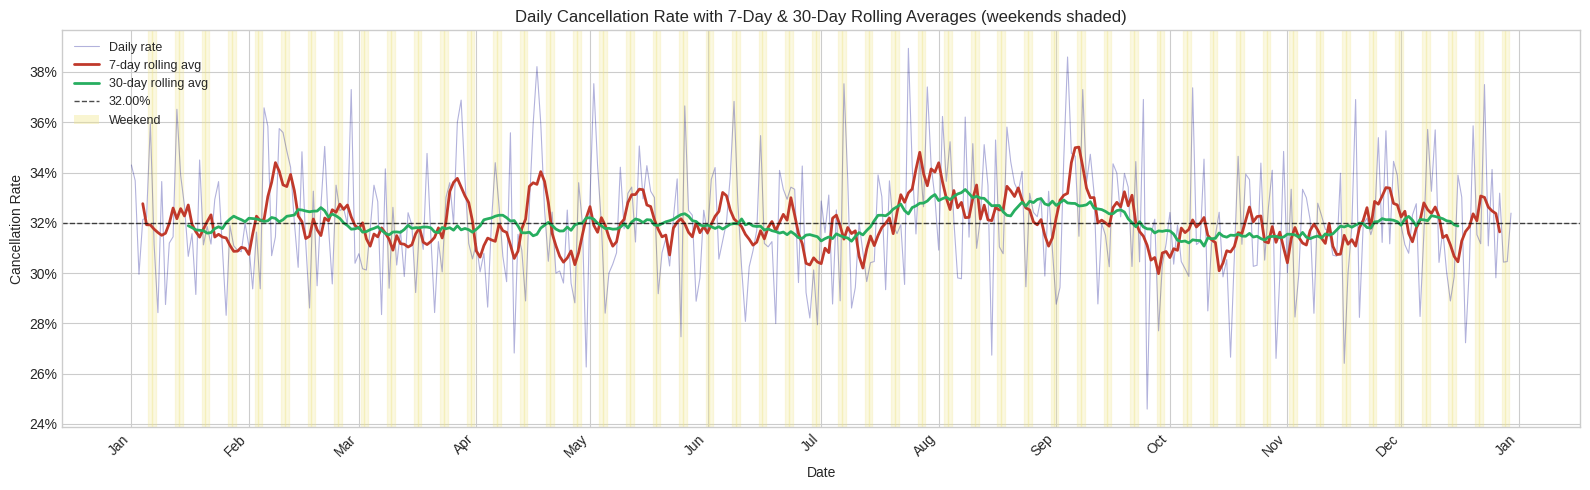

In [5]:
rolling_lineplot(
    daily["date"], daily["cancel_rate"],
    ylabel="Cancellation Rate",
    title="Daily Cancellation Rate with 7-Day & 30-Day Rolling Averages (weekends shaded)",
    daily_label="Daily rate",
    weekdays=daily["weekday"],
)

In [6]:
daily["date_ordinal"] = daily["date"].map(pd.Timestamp.toordinal)

spearman_trend(daily["date_ordinal"], daily["cancel_rate"],
               x_label="date", y_label="daily cancellation rate")

Spearman correlation (date vs daily cancellation rate): ρ = 0.0018, p = 9.7299e-01
  → No statistically significant monotonic trend (p ≥ 0.05)



The daily cancellation rate fluctuates around the overall mean with no visible upward or downward drift. The 7-day rolling average captures short-term weekly oscillations but shows no clear sustained spikes, while the 30-day rolling average is nearly flat and hugs the overall mean throughout the year, confirming the absence of any long-term trend or seasonal shift in cancellation behaviour.

The yellow-shaded weekend bands do not consistently coincide with peaks or troughs in the rate, suggesting that the day being a weekend alone does not shift cancellation behaviour in a visually obvious way. The gap between the 7-day and 30-day lines highlights that most of the day-to-day variation is short-lived noise rather than a meaningful structural change.

### date vs total rides

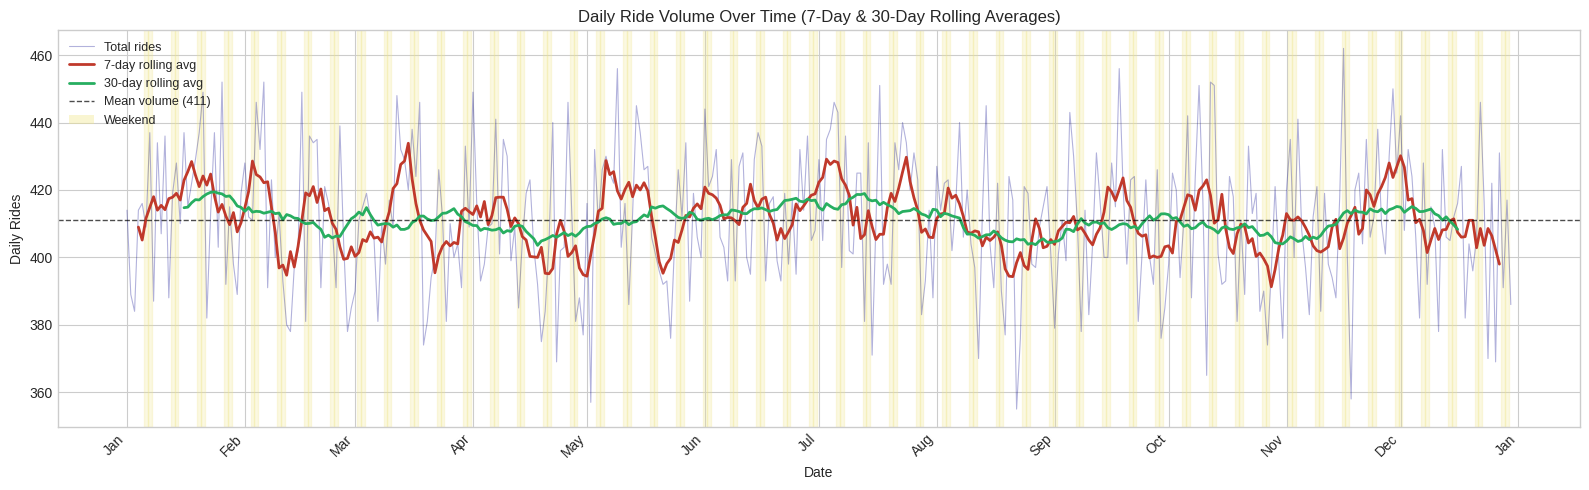

In [7]:
rolling_lineplot(
    daily["date"], daily["total"],
    ylabel="Daily Rides",
    title="Daily Ride Volume Over Time (7-Day & 30-Day Rolling Averages)",
    daily_label="Total rides",
    mean_label_fmt="Mean volume ({mean:,.0f})",
    weekdays=daily["weekday"],
    pct_axis=False,
)

Neither the daily ride volume nor the 7-day rolling average show a seasonal ramp-up or drop-off. The 30-day rolling average reinforces this, staying nearly flat around the overall mean throughout the observation period, which rules out any gradual long-term growth or decline in demand. Weekend shading reveals no obvious, consistent relationship between weekends and ride volume either. Overall, ride supply appears stationary, meaning any variation in cancellation rates is unlikely to be driven by volume-level shifts.

In [8]:
spearman_trend(daily["date_ordinal"], daily["total"],
               x_label="date", y_label="daily ride volume")

Spearman correlation (date vs daily ride volume): ρ = -0.0503, p = 3.3778e-01
  → No statistically significant monotonic trend (p ≥ 0.05)



With ρ ≈ 0 and p well above 0.05, there is no evidence that cancellation propensity is drifting over the calendar year.

The raw date feature is unlikely to add predictive power on its own but I can encode much more information so let's create other variables and analyse them:

### date-related new features analysis

In [9]:
df["date"] = pd.to_datetime(df["date"])

df["weekday"] = df["date"].dt.dayofweek       
df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter

print(f"DataFrame shape: {df.shape}")
df[["date", "weekday", "month", "day_of_month", "week_of_year", "quarter"]].head(10)

DataFrame shape: (150000, 12)


,date,weekday,month,day_of_month,week_of_year,quarter
0,2024-01-01,0,1,1,1,1
1,2024-01-01,0,1,1,1,1
2,2024-01-01,0,1,1,1,1
3,2024-01-01,0,1,1,1,1
4,2024-01-01,0,1,1,1,1
5,2024-01-01,0,1,1,1,1
6,2024-01-01,0,1,1,1,1
7,2024-01-01,0,1,1,1,1
8,2024-01-01,0,1,1,1,1
9,2024-01-01,0,1,1,1,1


### weekday vs. target

Weekday is a cyclical ordinal feature because Sunday goes before Monday again but i will treat is as a nominal so instead of using Spearman that would assume a linear ordering with endpoints, I will use chi-square


1. What the rates look like per category, and which ones visually differ from the mean?
2. Is the cancellation rate independent of day-of-week aka do the proportions differ more than chance alone would produce?
3.	How strong the association is (not "how much difference between days")
4. Which specific days deviate from expected and in which direction?


Overall cancellation rate: 0.3200 (32.00%)



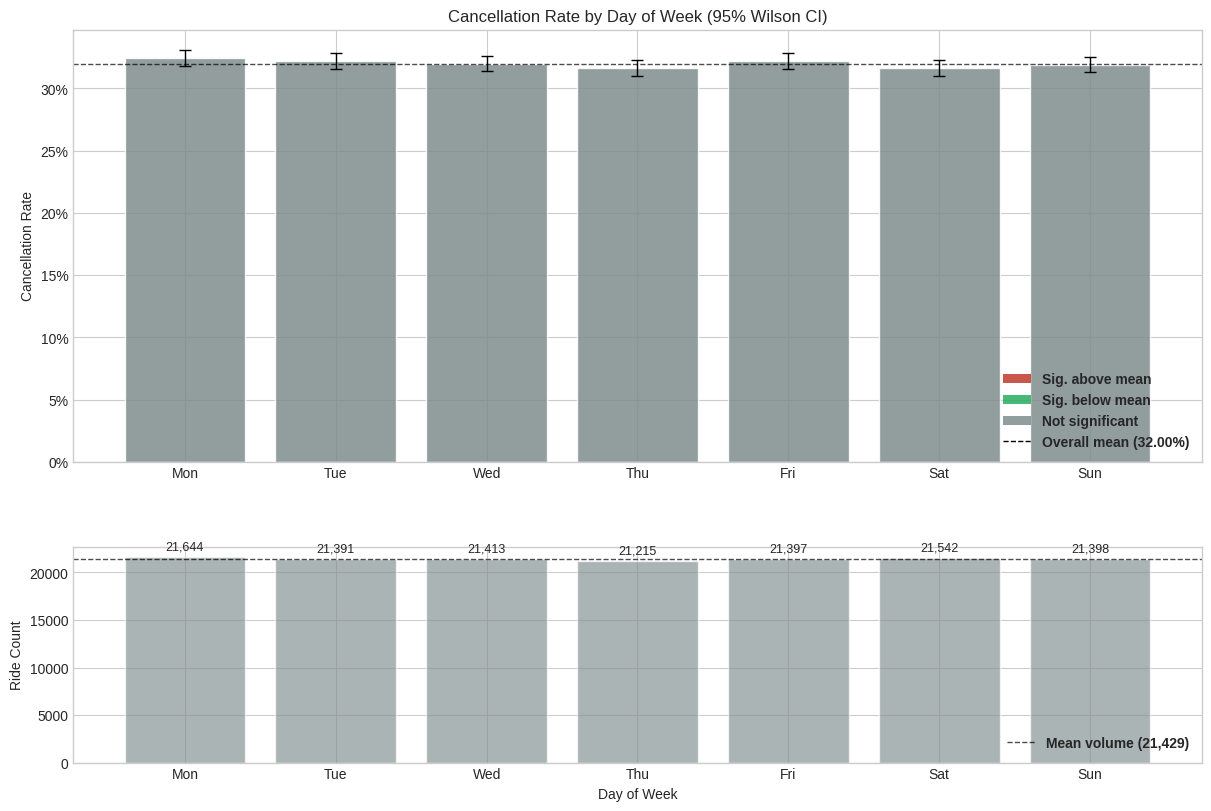


Chi-square: χ² = 5.28, dof = 6, p = 5.0802e-01
Cramér's V = 0.0059

No category has a standardized residual above 2 — none stand out.

All standardized residuals:


,Not Cancelled,Cancelled
Mon,-0.782410,1.140549
Tue,-0.355537,0.518280
Wed,0.017900,-0.026094
Thu,0.622767,-0.907831
Fri,-0.314699,0.458749
Sat,0.664622,-0.968844
Sun,0.152206,-0.221876


In [10]:
overall_rate = df["is_cancelled"].mean()
print(f"Overall cancellation rate: {overall_rate:.4f} ({overall_rate:.2%})\n")

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

wd_results = nominal_vs_binary(
    df, feature_col="weekday", target_col="is_cancelled",
    labels=day_labels, feature_label="Day of Week",
    figsize=(12, 8)
)
wd = wd_results["grouped"]
wd["not_cancelled"] = wd["total"] - wd["cancelled"]

All bars grey and the volume is flat. This mean that the day of week doesn't matter at all. 

Just to make a complete explanation of the data I use chi-quare, Cramer's and the standarized residuals table. I also have to keep in mind that my dataset is >100K rows so chi/square becomes sensitive. 

p = 0.508 makes us we fail to reject the null hypothesis! The differences in cancellation rates across days of the week are not statistically significant so there is no evidence that weekday influences cancellation.

Cramér's V = 0.0059 confirms it from the effect-size side because it's too close to zero.

The standardized residuals table shows that every single residual has |value| < 2. This means no individual day departs meaningfully from what I'd expect under independence. 

### month vs target

Following the same logic on this ordinal cyclical feature...

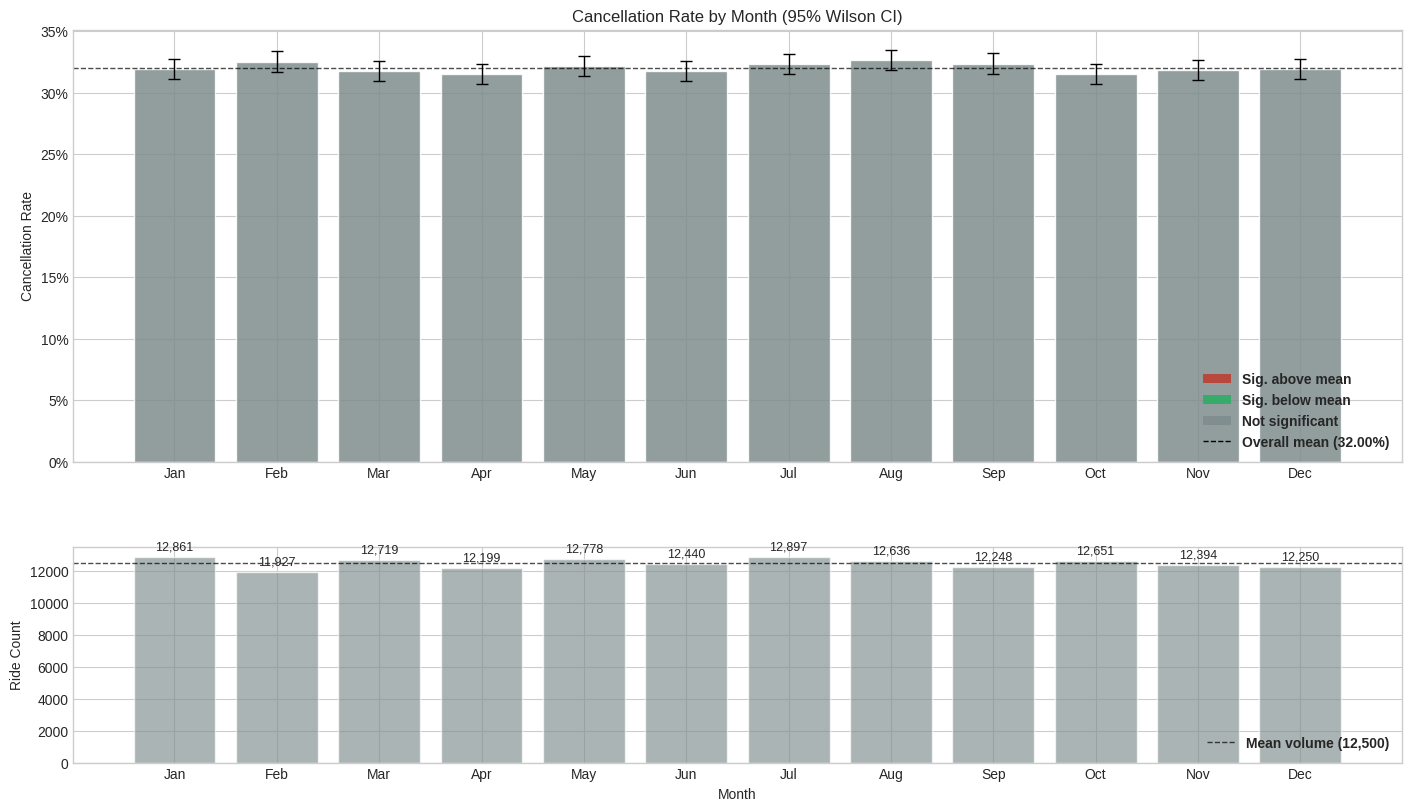


Chi-square: χ² = 9.06, dof = 11, p = 6.1654e-01
Cramér's V = 0.0078

No category has a standardized residual above 2 — none stand out.

All standardized residuals:


,Not Cancelled,Cancelled
Jan,0.144572,-0.210748
Feb,-0.681342,0.993218
Mar,0.344948,-0.502844
Apr,0.677217,-0.987205
May,-0.172075,0.250841
Jun,0.389241,-0.567411
Jul,-0.437382,0.637589
Aug,-0.835854,1.218456
Sep,-0.478187,0.697071
Oct,0.682691,-0.995184


In [11]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
present_months = sorted(df["month"].unique())
present_labels = [month_labels[m - 1] for m in present_months]

mo_results = nominal_vs_binary(
    df, feature_col="month", target_col="is_cancelled",
    labels=present_labels, feature_label="Month",
    figsize=(14, 8)
)

### day of month vs target

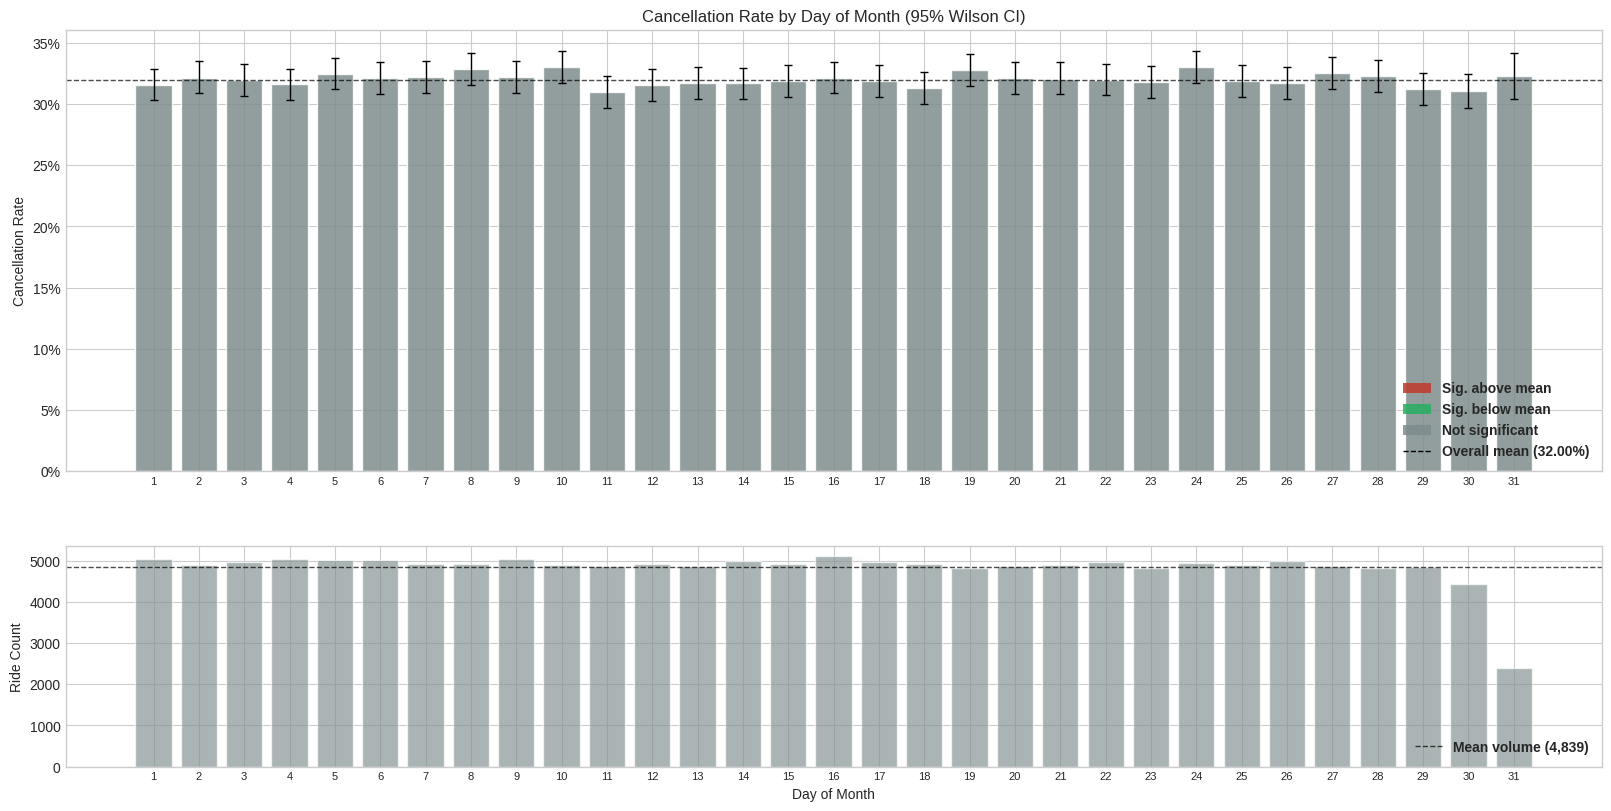


Chi-square: χ² = 18.38, dof = 30, p = 9.5201e-01
Cramér's V = 0.0111

No category has a standardized residual above 2 — none stand out.

All standardized residuals:


,Not Cancelled,Cancelled
1,0.367743,-0.536074
2,-0.137290,0.200133
3,0.021998,-0.032067
4,0.344435,-0.502096
5,-0.420486,0.612959
6,-0.118452,0.172672
7,-0.164689,0.240074
8,-0.753788,1.098826
9,-0.179717,0.261980
10,-0.877041,1.278495


In [12]:
dom_labels = [str(d) for d in sorted(df["day_of_month"].unique())]

dom_results = nominal_vs_binary(
    df, feature_col="day_of_month", target_col="is_cancelled",
    labels=dom_labels, feature_label="Day of Month",
    figsize=(16, 8), capsize=3, tick_fontsize=8,
    show_vol_labels=False
)

### week of year vs target

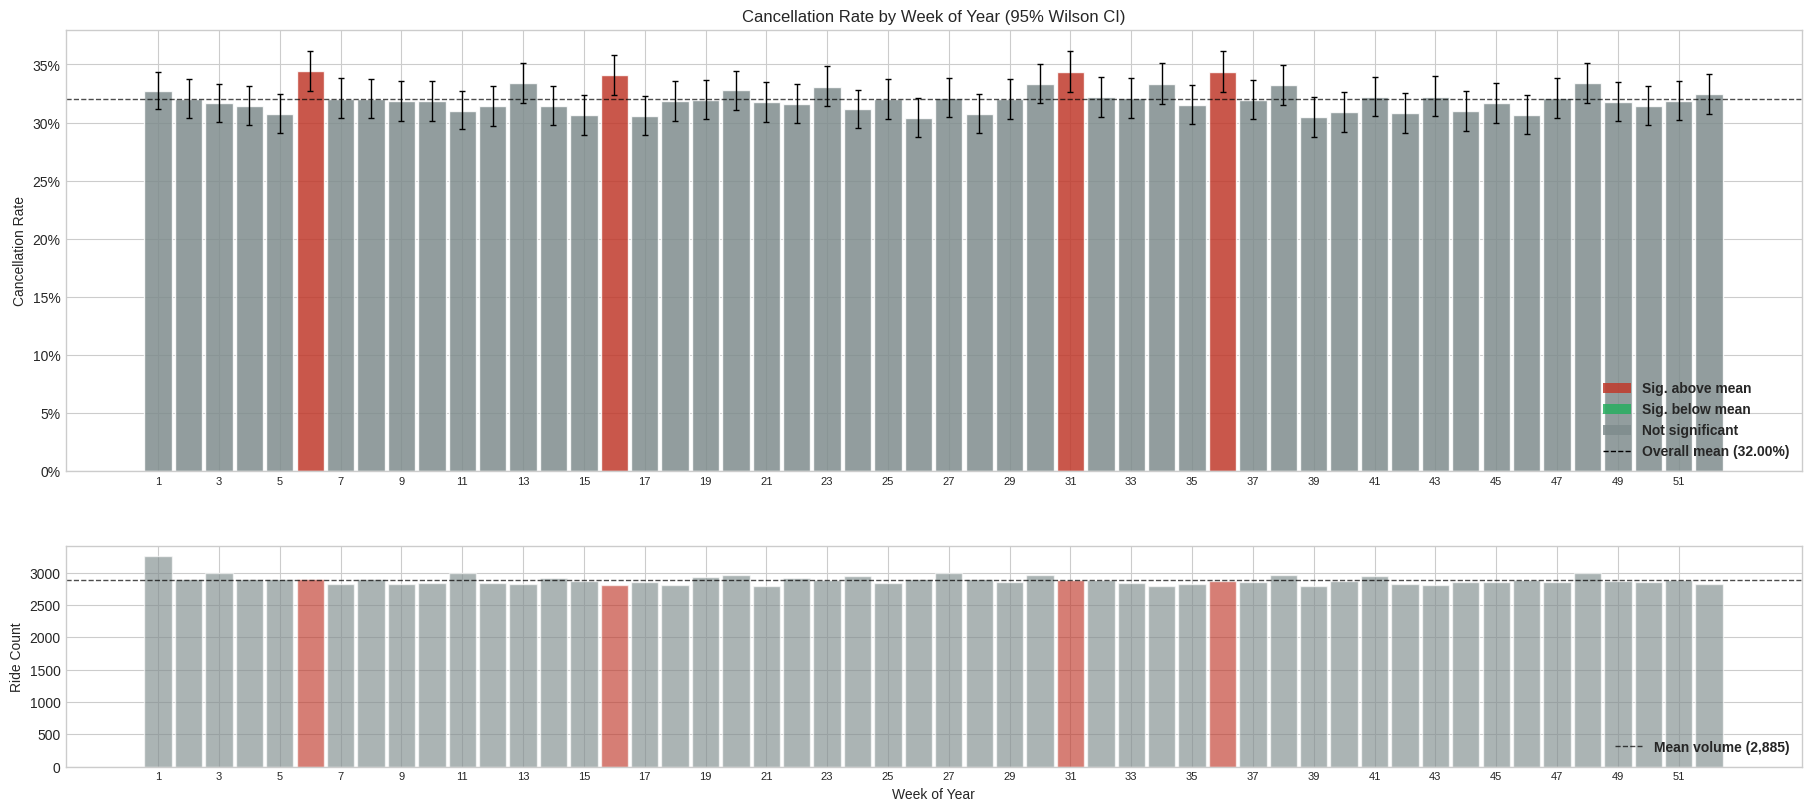


Chi-square: χ² = 72.39, dof = 51, p = 2.6052e-02
Cramér's V = 0.0220

Categories with |standardized residual| > 2:


,Not Cancelled,Cancelled
6,-1.591437,2.319898
31,-1.538131,2.242193
36,-1.537824,2.241745



All standardized residuals:


,Not Cancelled,Cancelled
1,-0.496134,0.723234
2,-0.029730,0.043339
3,0.236499,-0.344753
4,0.385021,-0.561259
5,0.831867,-1.212644
6,-1.591437,2.319898
7,-0.037431,0.054565
8,-0.021629,0.031530
9,0.092225,-0.134440
10,0.100999,-0.147230


In [13]:
woy_labels = [str(w) for w in sorted(df["week_of_year"].unique())]

woy_results = nominal_vs_binary(
    df, feature_col="week_of_year", target_col="is_cancelled",
    labels=woy_labels, feature_label="Week of Year",
    figsize=(18, 8), bar_width=0.9, capsize=2,
    tick_step=2, tick_fontsize=8, show_vol_labels=False
)

The chi-square test is marginally significant which at first glance suggests week-of-year matters. However, Cramér's shows that that the strenght of the effect is negligible . I guess that the association is statistically detectable only because 150k rows give the test enormous power to pick up trivially small deviations.

Only three weeks cross the |residual| > 2 threshold but they are isolated spikes rather than a sustained seasonal pattern and their residuals barely exceed 2. The remaining 49 weeks all sit comfortably within normal random variation.

In practical terms, week-of-year is statistically significant but practically irrelevant

### quarter vs target

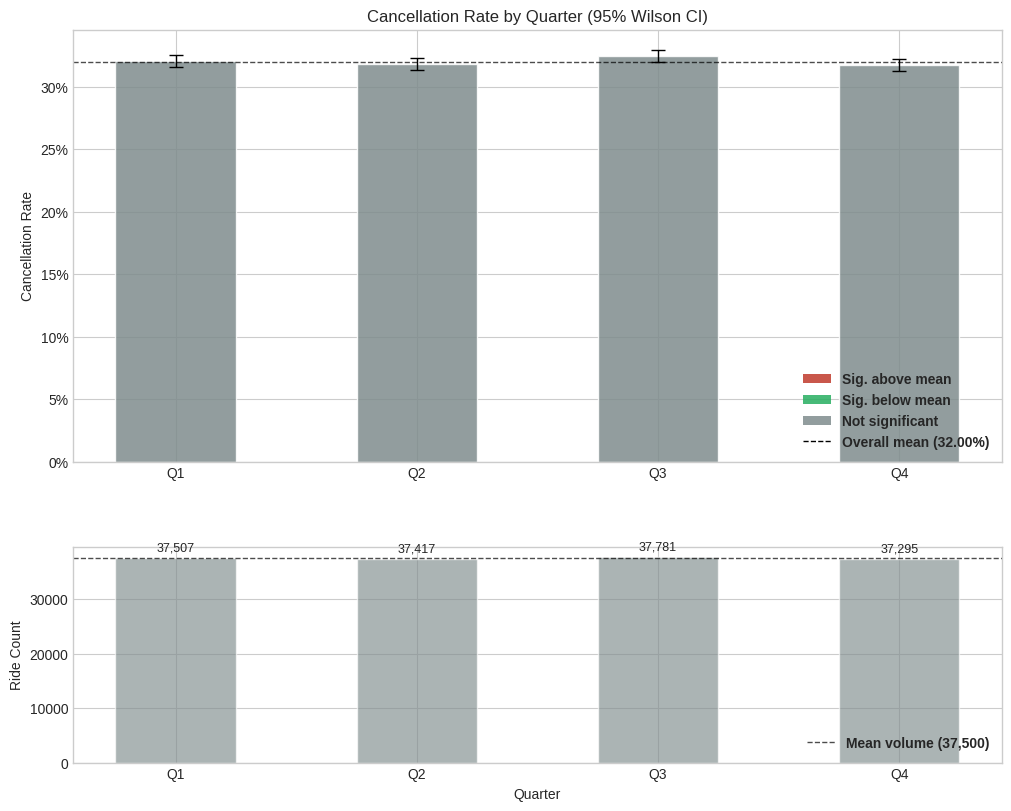


Chi-square: χ² = 5.19, dof = 3, p = 1.5870e-01
Cramér's V = 0.0059

No category has a standardized residual above 2 — none stand out.

All standardized residuals:


,Not Cancelled,Cancelled
Q1,-0.098684,0.143855
Q2,0.510562,-0.744266
Q3,-1.011203,1.474069
Q4,0.605337,-0.882423


In [14]:
qtr_labels = ["Q1", "Q2", "Q3", "Q4"]
present_q = sorted(df["quarter"].unique())
present_q_labels = [qtr_labels[q - 1] for q in present_q]

qt_results = nominal_vs_binary(
    df, feature_col="quarter", target_col="is_cancelled",
    labels=present_q_labels, feature_label="Quarter",
    figsize=(10, 8), bar_width=0.5, capsize=5
)

### time vs target

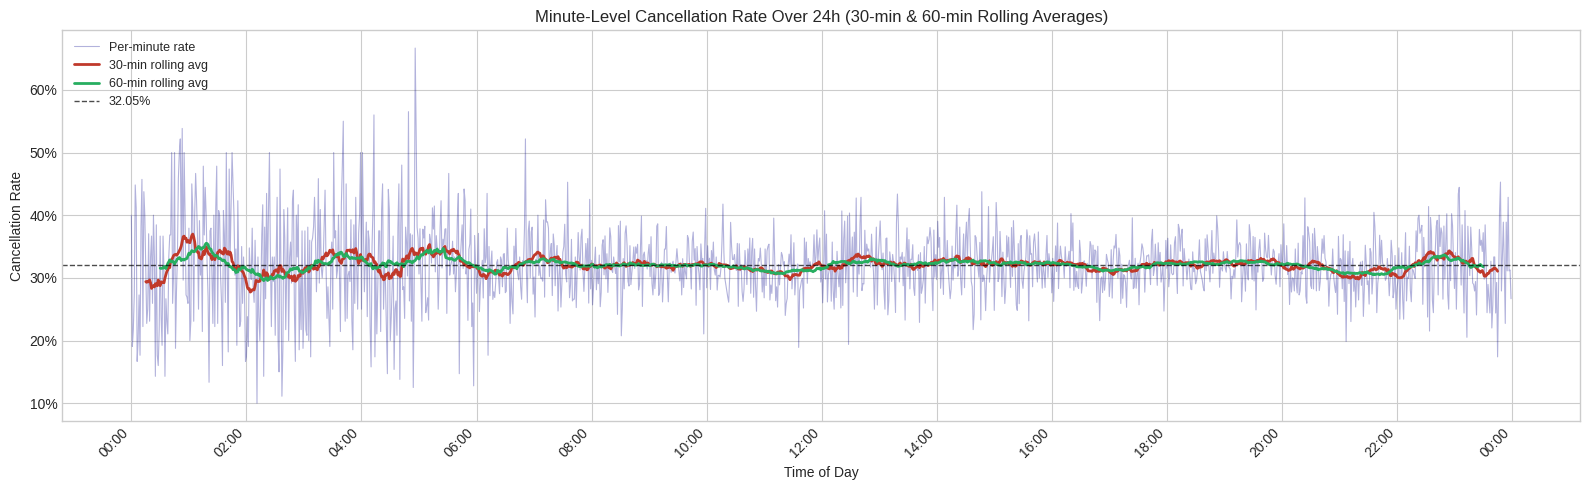

In [15]:
df["time_parsed"] = pd.to_datetime(df["time"], format="%H:%M:%S")
df["hour"] = df["time_parsed"].dt.hour

minutely = (
    df.assign(minute_bucket=df["time_parsed"].dt.floor("min"))
      .groupby("minute_bucket")["is_cancelled"]
      .agg(["sum", "count"])
      .reset_index()
)
minutely.columns = ["minute_bucket", "is_cancelled", "total"]
minutely["cancel_rate"] = minutely["is_cancelled"] / minutely["total"]

from matplotlib.dates import HourLocator, DateFormatter

rolling_lineplot(
    minutely["minute_bucket"], minutely["cancel_rate"],
    rolling_windows=(30, 60),
    ylabel="Cancellation Rate",
    xlabel="Time of Day",
    title="Minute-Level Cancellation Rate Over 24h (30-min & 60-min Rolling Averages)",
    daily_label="Per-minute rate",
    rolling_label_fmt="{win}-min rolling avg",
    shade_weekends=False,
    xaxis_locator=HourLocator(interval=2),
    xaxis_formatter=DateFormatter("%H:%M"),
)

In [16]:
minutely["minute_ordinal"] = range(len(minutely))
spearman_trend(minutely["minute_ordinal"], minutely["cancel_rate"],
               x_label="time of day (minute)", y_label="cancellation rate")

Spearman correlation (time of day (minute) vs cancellation rate): ρ = -0.0123, p = 6.4067e-01
  → No statistically significant monotonic trend (p ≥ 0.05)



Cool finding! Spearman shows nothing because the average cancellation rate is essentially flat acroos the 24h-cycle but what is is happening between 0h and 6h? I guess it's a small-sample variance effect showing here producing higher noise because each bucket has far fewer data points than during the day. 


### time-related new features analysis

Engineer new binary/categorical features from the hour of day and analyse their relationship with cancellation.

In [17]:
df["is_night"]    = df["hour"].isin([*range(0, 6), *range(22, 24)]).astype(int)
df["is_business"] = df["hour"].isin(range(9, 18)).astype(int)
df["is_rush"]     = df["hour"].isin([7, 8, 9, 17, 18, 19]).astype(int)

print(f"DataFrame shape: {df.shape}")
df[["time", "hour", "is_night", "is_business", "is_rush"]].head()

DataFrame shape: (150000, 17)


,time,hour,is_night,is_business,is_rush
0,00:19:34,0,1,0,0
1,01:35:18,1,1,0,0
2,01:37:50,1,1,0,0
3,01:48:03,1,1,0,0
4,01:49:56,1,1,0,0


#### hour vs target

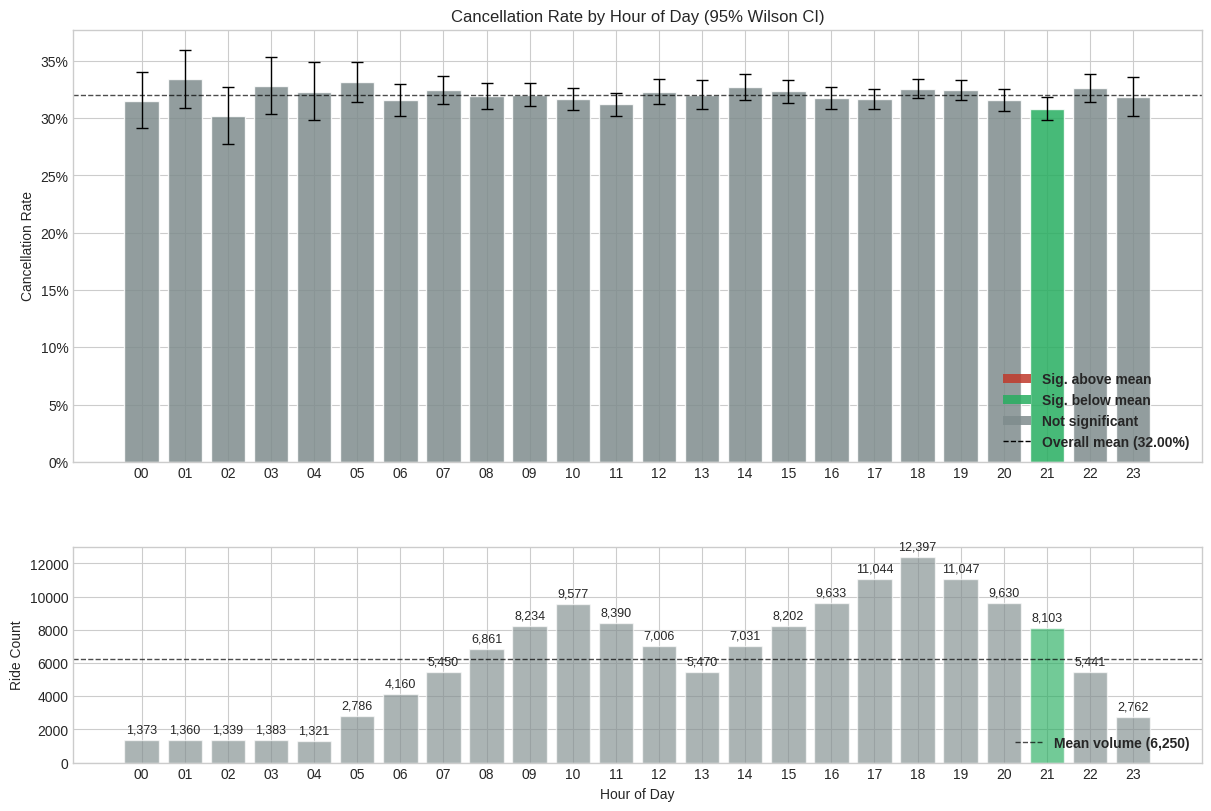


Chi-square: χ² = 22.54, dof = 23, p = 4.8786e-01
Cramér's V = 0.0123

No category has a standardized residual above 2 — none stand out.

All standardized residuals:


,Not Cancelled,Cancelled
00,0.208146,-0.303422
01,-0.618207,0.901184
02,0.811272,-1.182622
03,-0.373044,0.543801
04,-0.142803,0.208170
05,-0.723252,1.054312
06,0.342192,-0.498827
07,-0.410665,0.598641
08,0.066174,-0.096465
09,-0.055060,0.080263


In [18]:
hour_labels = [f"{h:02d}" for h in range(24)]

hour_results = nominal_vs_binary(
    df, feature_col="hour", target_col="is_cancelled",
    labels=hour_labels,
    feature_label="Hour of Day",
)

No hour shows a statistically significant deviation from the overall cancellation rate. The only mild outlier is hour 21, which has slightly above-average volume and a marginally lower cancellation rate. I think that it is possibly reflecting post-dinner return trips (a quick Google search showed me that a typical Indian dinner time falls between 20:30 and 22:00). However, both the chi-square test and Cramér's V confirm that hour of day carries no meaningful predictive signal for cancellation.

#### is_night vs target

Night is defined as hours 22-23 and 0-5 (10 PM to 5:59 AM).

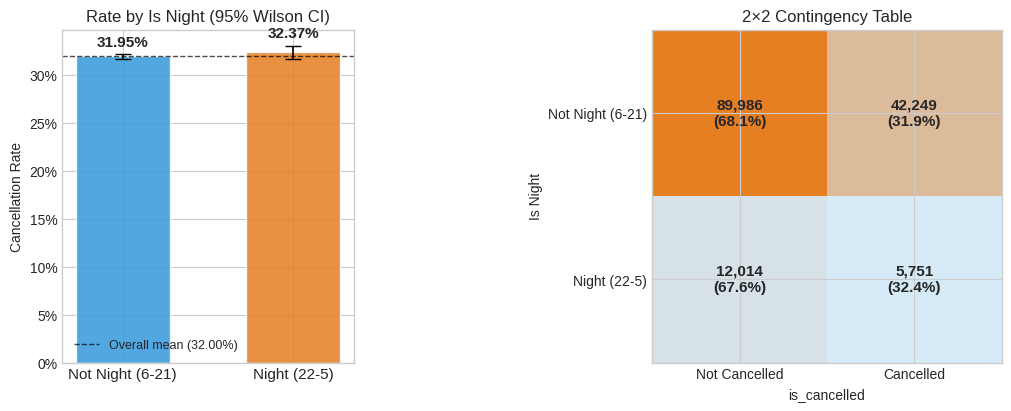

Fisher's exact test:  p = 2.5823e-01
Phi coefficient:      φ = +0.0029
  → negligible positive association

Odds ratio:           OR = 1.0196  95% CI [0.9860, 1.0543]
  → CI contains 1 — no significant difference in odds


In [19]:
night_results = binary_vs_binary(
    df, feature_col="is_night", target_col="is_cancelled",
    labels=("Not Night (6-21)", "Night (22-5)"),
    feature_label="Is Night",
)

Fisher's exact test is non-significant (p = 0.26) and the odds ratio of 1.02 has a 95% CI of [0.99, 1.05] that straddles 1, confirming no meaningful difference in cancellation odds between night and non-night hours. The phi coefficient is essentially zero (φ = +0.003). The bar chart reinforces this: both groups sit right on the overall mean with heavily overlapping confidence intervals. In short, riding at night does not increase or decrease the likelihood of cancellation.

#### is_business vs target

Business hours are defined as 9:00 AM – 5:59 PM.

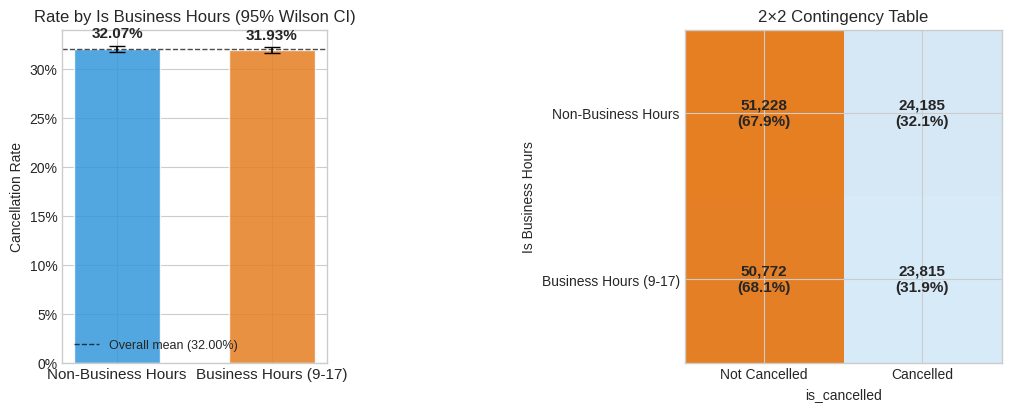

Fisher's exact test:  p = 5.6111e-01
Phi coefficient:      φ = -0.0015
  → negligible negative association

Odds ratio:           OR = 0.9935  95% CI [0.9722, 1.0153]
  → CI contains 1 — no significant difference in odds


In [20]:
business_results = binary_vs_binary(
    df, feature_col="is_business", target_col="is_cancelled",
    labels=("Non-Business Hours", "Business Hours (9-17)"),
    feature_label="Is Business Hours",
)

The result mirrors the night analysis. Fisher's p = 0.56 is far from significant, and the odds ratio of 0.99 with a CI of [0.97, 1.02] tightly brackets 1. The phi coefficient is negligible (φ = −0.002), with the negative sign indicating a trivially lower cancellation tendency during business hours but the magnitude is meaningless. Whether a ride is booked during standard working hours or outside them has no detectable effect on cancellation.

#### is_rush vs target

Rush hours are defined as 7-9 AM and 5-7 PM (hours 7, 8, 9, 17, 18, 19).

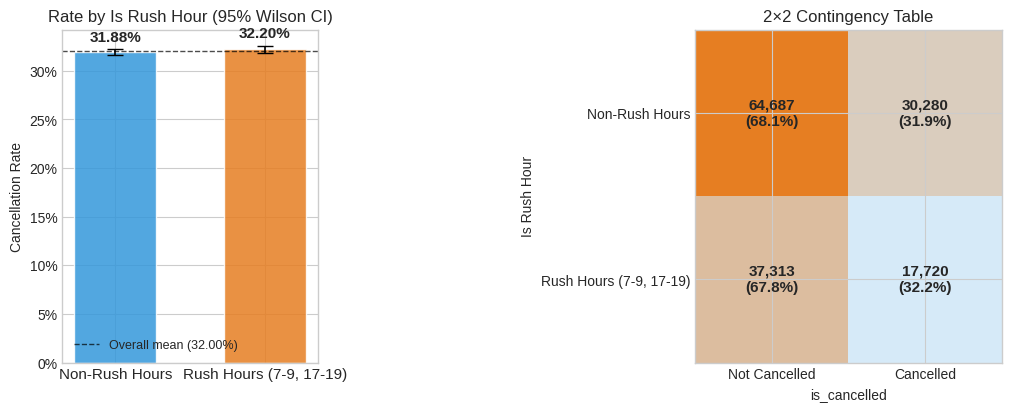

Fisher's exact test:  p = 2.1063e-01
Phi coefficient:      φ = +0.0032
  → negligible positive association

Odds ratio:           OR = 1.0145  95% CI [0.9920, 1.0376]
  → CI contains 1 — no significant difference in odds


In [21]:
rush_results = binary_vs_binary(
    df, feature_col="is_rush", target_col="is_cancelled",
    labels=("Non-Rush Hours", "Rush Hours (7-9, 17-19)"),
    feature_label="Is Rush Hour",
)

Same story again. Fisher's p = 0.21, OR = 1.01 with CI [0.99, 1.04], and φ = +0.003. Rush-hour rides cancel at virtually the same rate as non-rush rides. The confidence intervals overlap almost entirely with the overall mean.



## Non-temporal features


### vehicle_type vs target

Nominal categorical with 7 categories. All groups have at least ~4,400 rides, so Wilson CIs will be tight.

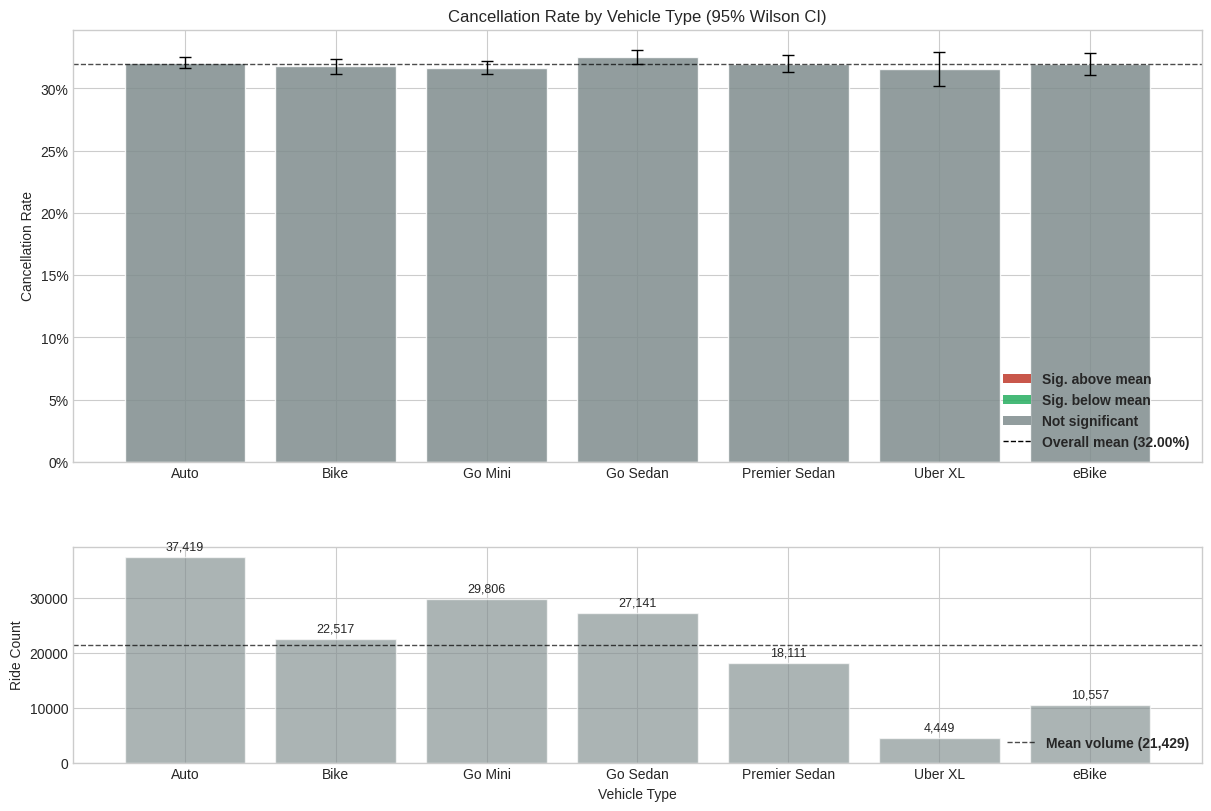


Chi-square: χ² = 5.67, dof = 6, p = 4.6126e-01
Cramér's V = 0.0061

No category has a standardized residual above 2 — none stand out.

All standardized residuals:


,Not Cancelled,Cancelled
Auto,-0.187569,0.273426
Bike,0.407629,-0.594217
Go Mini,0.673756,-0.982160
Go Sedan,-1.014925,1.479495
Premier Sedan,-0.004325,0.006305
Uber XL,0.357799,-0.521578
eBike,0.026438,-0.038539


In [22]:
vtype_order = sorted(df["vehicle_type"].unique())
vtype_results = nominal_vs_binary(
    df, feature_col="vehicle_type", target_col="is_cancelled",
    labels=vtype_order,
    feature_label="Vehicle Type",
)

All seven vehicle types cluster tightly around the overall mean (31.6% to 32.5% — less than 1 pp spread). Every bar is grey (CI overlaps the mean), and the chi-square test is non-significant (p = 0.46) with a near-zero Cramér's V (0.006). No standardised residual exceeds 2. Vehicle type carries no predictive signal for cancellation.



### pickup_location vs target

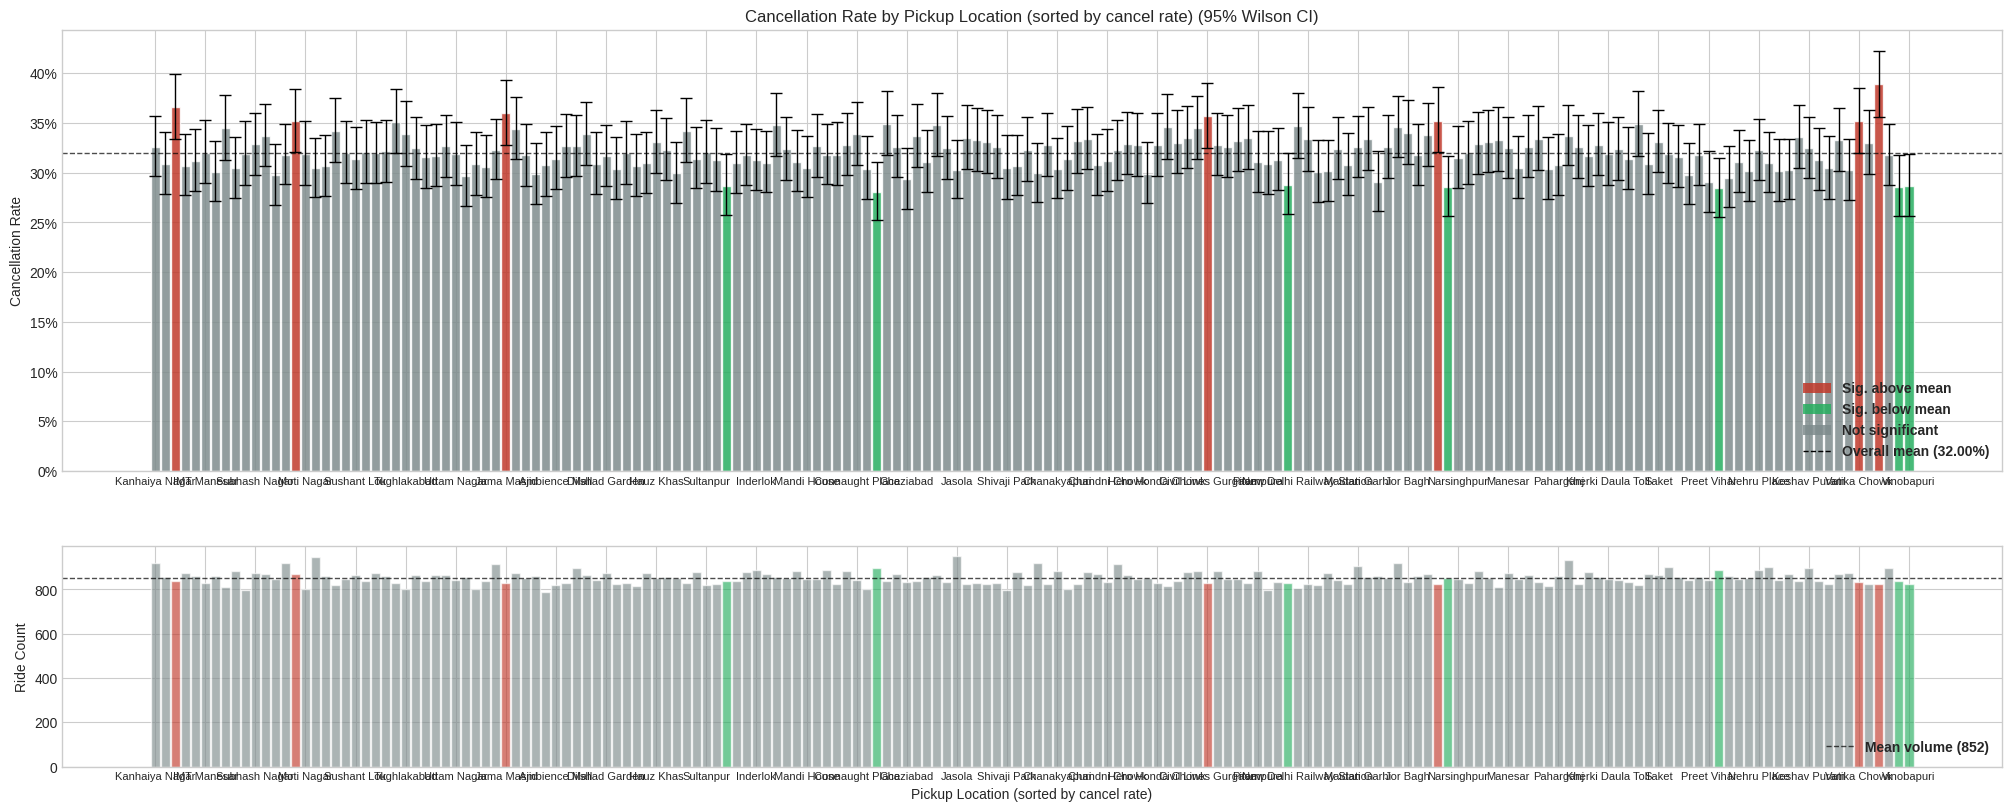


Chi-square: χ² = 203.70, dof = 175, p = 6.7753e-02
Cramér's V = 0.0369

Categories with |standardized residual| > 2:


,Not Cancelled,Cancelled
RK Puram,-1.612690,2.350879
Jama Masjid,-1.391588,2.028570
Gurgaon Railway Station,1.434952,-2.091784
Netaji Subhash Place,-2.394247,3.490184



All standardized residuals:


,Not Cancelled,Cancelled
Kanhaiya Nagar,-0.209728,0.305728
Subhash Chowk,0.395785,-0.576951
RK Puram,-1.612690,2.350879
Welcome,0.466248,-0.679667
Yamuna Bank,0.284667,-0.414970
...,...,...
Qutub Minar,-0.337760,0.492366
Netaji Subhash Place,-2.394247,3.490184
Faridabad Sector 15,0.097285,-0.141816
Akshardham,1.196167,-1.743698


In [23]:
pickup_rate = (df.groupby("pickup_location", observed=True)["is_cancelled"]
                 .mean().sort_values())
pickup_sorted = pickup_rate.index.tolist()

pickup_results = nominal_vs_binary(
    df, feature_col="pickup_location", target_col="is_cancelled",
    labels=pickup_sorted,
    feature_label="Pickup Location (sorted by cancel rate)",
    figsize=(20, 8), tick_step=5, tick_fontsize=8,
    bar_width=0.9, show_vol_labels=False,
)

Individual cancellation rates range from ~28% to ~39%, which at first glance seems like meaningful variation. However, the chi-square test is only marginally significant (p = 0.068, above 0.05) and Cramér's V is just 0.037. With 176 independent groups, some spread is expected purely by chance. A handful of locations do cross the significance threshold (standardised residuals > 2), but with this many comparisons, a few false positives are likely without multiple-testing correction. 

I do not have enough domain knowledge to justify grouping before looking at the data and I do not want to fall on selection bias. I will leave it as it is and in any case, I will perform target encoding with regularisation or smoothing when modelling but I still have to decide it.

### drop_location vs target

Same structure as pickup — 176 high-cardinality categories, sorted by rate.

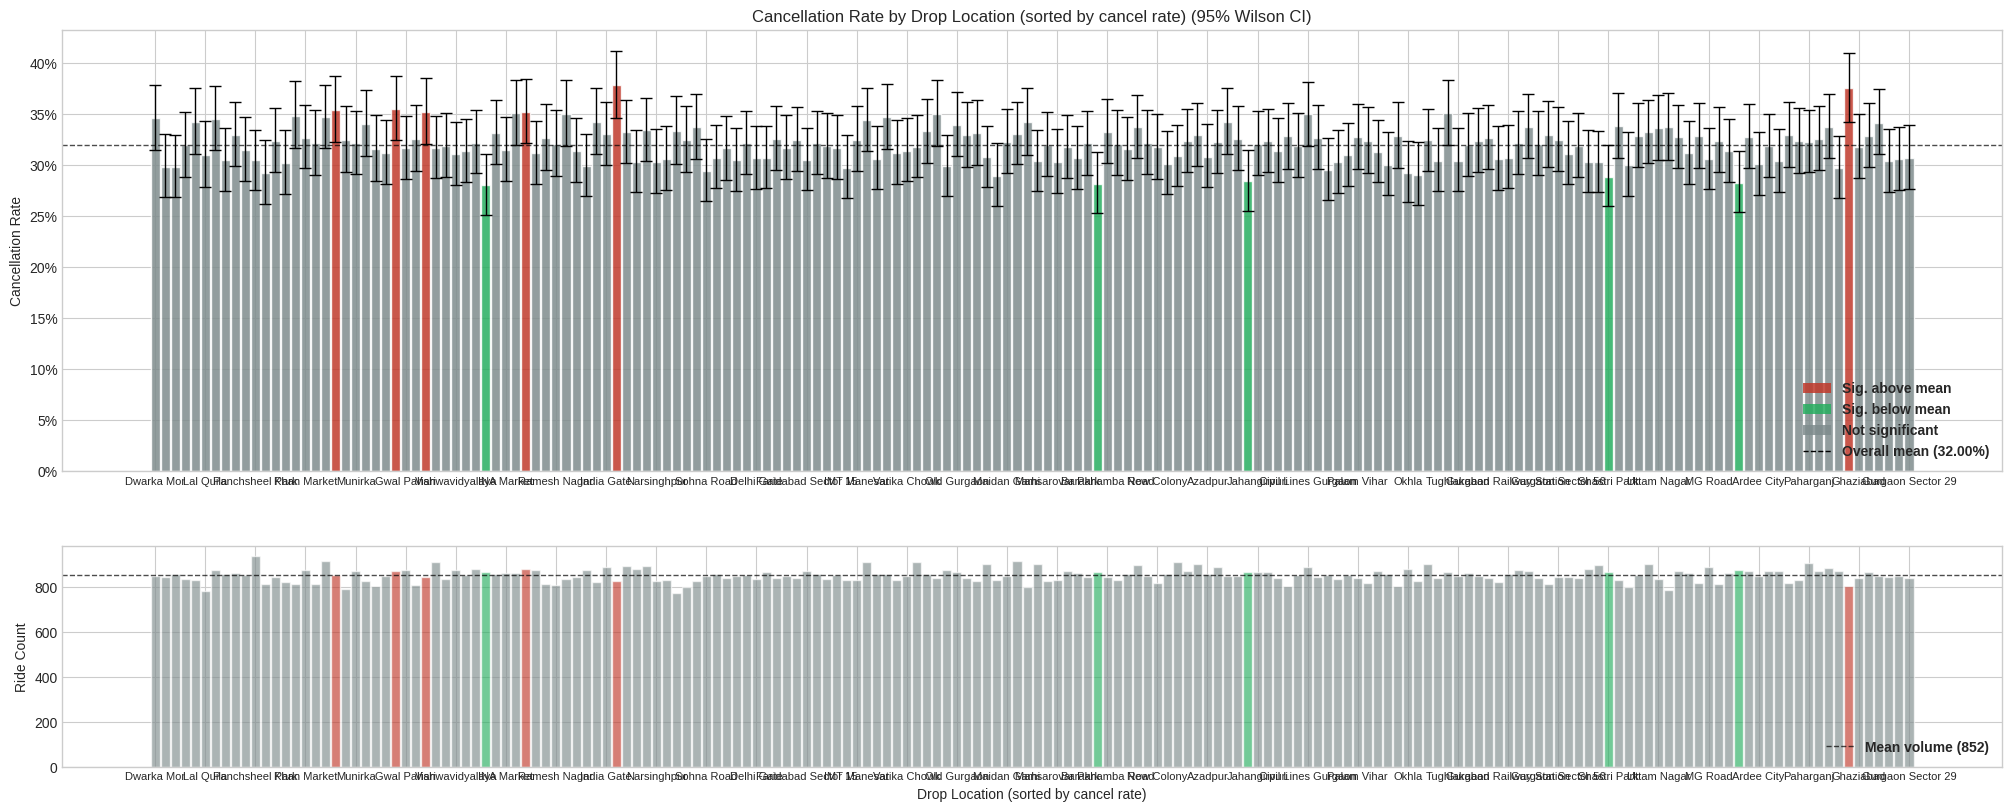


Chi-square: χ² = 201.57, dof = 175, p = 8.2376e-02
Cramér's V = 0.0367

Categories with |standardized residual| > 2:


,Not Cancelled,Cancelled
Ashram,1.418401,-2.067658
Rithala,-2.039290,2.972751
Botanical Garden,1.377217,-2.007621
RK Puram,-1.899546,2.769041



All standardized residuals:


,Not Cancelled,Cancelled
Dwarka Mor,-0.915079,1.333946
Mayur Vihar,0.767600,-1.118960
Sultanpur,0.784205,-1.143166
Noida Extension,0.021810,-0.031793
Sarojini Nagar,-0.774505,1.129026
...,...,...
Connaught Place,-0.298005,0.434414
Bhikaji Cama Place,-0.762460,1.111467
Chhatarpur,0.572024,-0.833862
Vasant Kunj,0.514714,-0.750318


In [24]:
drop_rate = (df.groupby("drop_location", observed=True)["is_cancelled"]
               .mean().sort_values())
drop_sorted = drop_rate.index.tolist()

drop_results = nominal_vs_binary(
    df, feature_col="drop_location", target_col="is_cancelled",
    labels=drop_sorted,
    feature_label="Drop Location (sorted by cancel rate)",
    figsize=(20, 8), tick_step=5, tick_fontsize=8,
    bar_width=0.9, show_vol_labels=False,
)

The picture is nearly identical to pickup location: rates span ~28% to ~38%, chi-square is marginally non-significant (p = 0.082), and Cramér's V is 0.037. The same caveats about multiple comparisons apply. Drop location, like pickup location, shows at most a faint signal that would require careful regularisation or target encoding to extract value from in a model.

As commented in pick_up locations I will consider target encoding in the future

### avg_vtat vs target

It has 7% missing values which are excluded from this analysis. Shapiro-Wilk rejects normality, so non-parametric tests are used.

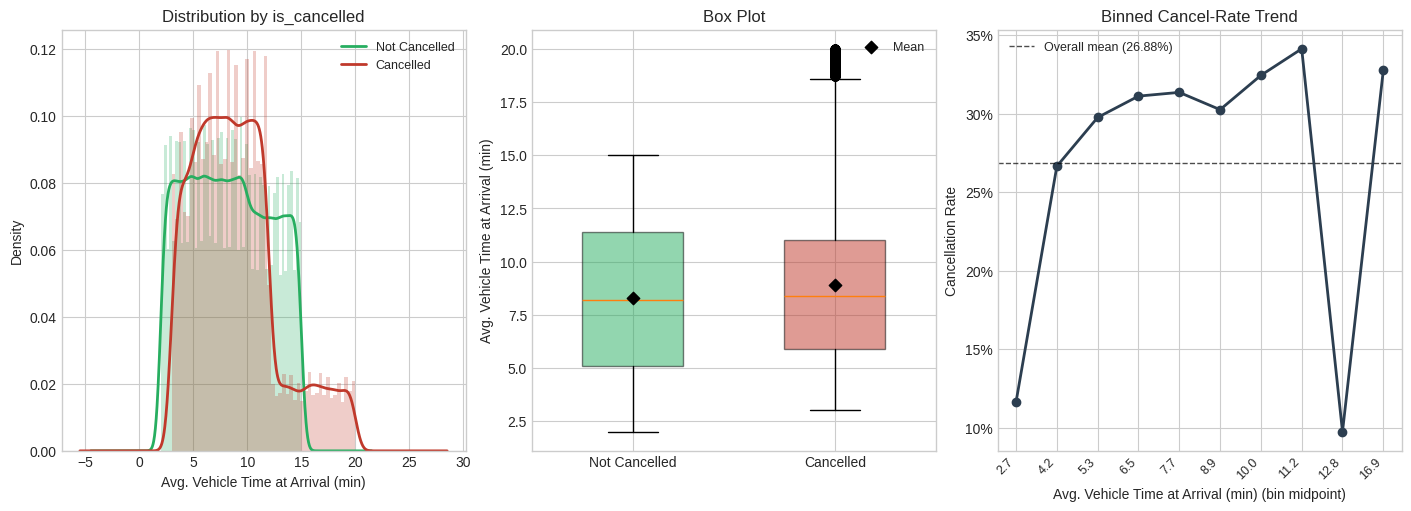

Mann-Whitney U test:       U = 1,794,477,356,  p = 4.2200e-70
  → Distributions differ significantly (p < 0.05)

Point-biserial correlation: r = +0.0721,  p = 5.3630e-160
  → negligible positive association

Cohen's d:                 d = +0.1630
  → negligible effect size

Group means:  Not Cancelled = 8.291,  Cancelled = 8.905  (Δ = +0.613)


In [25]:
vtat_results = continuous_vs_binary(
    df, feature_col="avg_vtat", target_col="is_cancelled",
    feature_label="Avg. Vehicle Time at Arrival (min)",
)

This is the first feature that shows a statistically significant association with cancellation!

However, the summary statistics are misleading here. Cohen's and the KDE overlap suggest a weak effect, but that is because these metrics assume a roughly monotonic or linear relationship. A closer look at the binned trend panel reveals something far more interesting: the relationship is highly non-linear and non-monotonic, let's take a look at it



### avg_vtat-related features analysis

Let's break it into fine-grained 0.5-min buckets to see the true shape of the relationship.

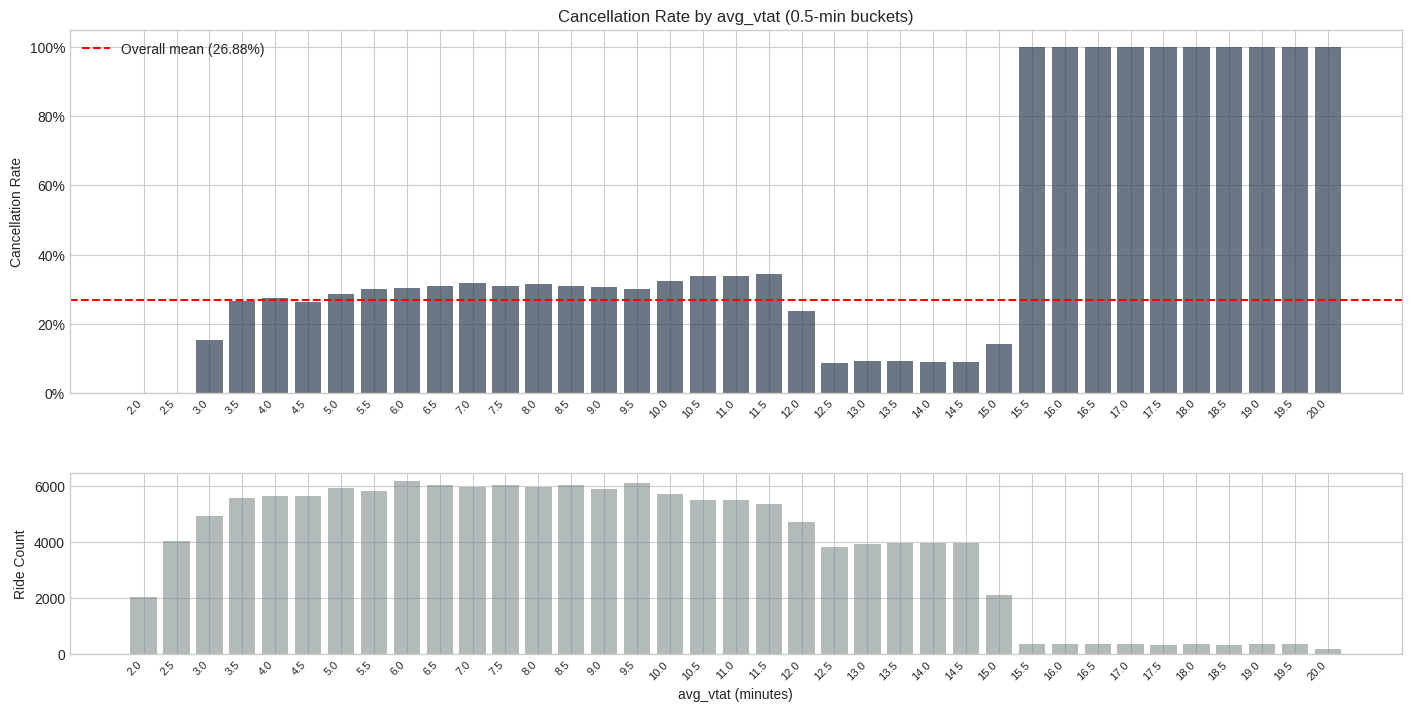

Zone summary:
  Zero-cancel          [ 2.0 –  2.9]:  n =  7,693  rate = 0.0000
  Low                  [ 3.0 –  5.0]:  n = 23,618  rate = 0.2634
  Baseline             [ 5.1 – 11.9]:  n = 80,580  rate = 0.3165
  Dip                  [12.0 – 15.0]:  n = 24,088  rate = 0.0937
  Guaranteed-cancel    [15.1 – 20.0]:  n =  3,521  rate = 1.0000


In [26]:
vtat_zones = [
    (2.0, 2.9, "Zero-cancel"),
    (3.0, 5.0, "Low"),
    (5.1, 11.9, "Baseline"),
    (12.0, 15.0, "Dip"),
    (15.1, 20.0, "Guaranteed-cancel"),
]

zone_breakdown(
    df, feature_col="avg_vtat", target_col="is_cancelled",
    zones=vtat_zones,
    feature_label="avg_vtat",
)

The pattern is striking and clearly non-monotonic! And I can see five distinct behavioural zones:

- Zero-cancel (2.0 – 2.9 min): Cancel rate is exactly 0%. The vehicle arrives almost instantly and no one cancels.
- Low (3.0 – 5.0 min): Cancel rate drops to ~26%, noticeably below the overall mean. Short waits still discourage cancellation.
- Baseline (5.1 – 11.9 min): The bulk of the data. Cancel rate hovers around ~31%, right at the overall mean.
- Dip (12.0 – 15.0 min): Unexpectedly, the rate plunges to ~9% despite a long wait. This could reflect a sunk-cost effect (riders who have waited this long are committed) or some artefact of the timeout mechanics.
- Guaranteed-cancel (15.1 – 20.0 min): Every single ride is cancelled (100%). This almost certainly reflects a system-level auto-cancellation timeout rather than rider choice.

This non-linear structure means that zone-based features can capture the real signal!

### vtat_zone vs target

In [27]:
df["vtat_zone"] = pd.cut(
    df["avg_vtat"],
    bins=[0, 2.9, 5.0, 11.9, 15.0, 20.0],
    labels=["instant", "short", "normal", "dip", "timeout"],
    include_lowest=True,
)

df["is_instant_arrival"] = (df["avg_vtat"] <= 2.9).astype("Int8")
df["is_timeout"]         = (df["avg_vtat"] > 15.0).astype("Int8")
df["is_long_wait"]       = (df["avg_vtat"] > 11.9).astype("Int8")

print(f"DataFrame shape: {df.shape}\n")

print("vtat_zone value counts:")
print(df["vtat_zone"].value_counts(dropna=False).sort_index())
print(f"\nis_instant_arrival:  {df['is_instant_arrival'].sum()} ({df['is_instant_arrival'].mean():.1%})")
print(f"is_timeout:          {df['is_timeout'].sum()} ({df['is_timeout'].mean():.1%})")
print(f"is_long_wait:        {df['is_long_wait'].sum()} ({df['is_long_wait'].mean():.1%})")

DataFrame shape: (150000, 21)

vtat_zone value counts:
vtat_zone
instant     6869
short      24442
normal     80580
dip        24088
timeout     3521
NaN        10500
Name: count, dtype: int64

is_instant_arrival:  7693 (5.1%)
is_timeout:          3521 (2.3%)
is_long_wait:        27609 (18.4%)


#### vtat_zone vs target

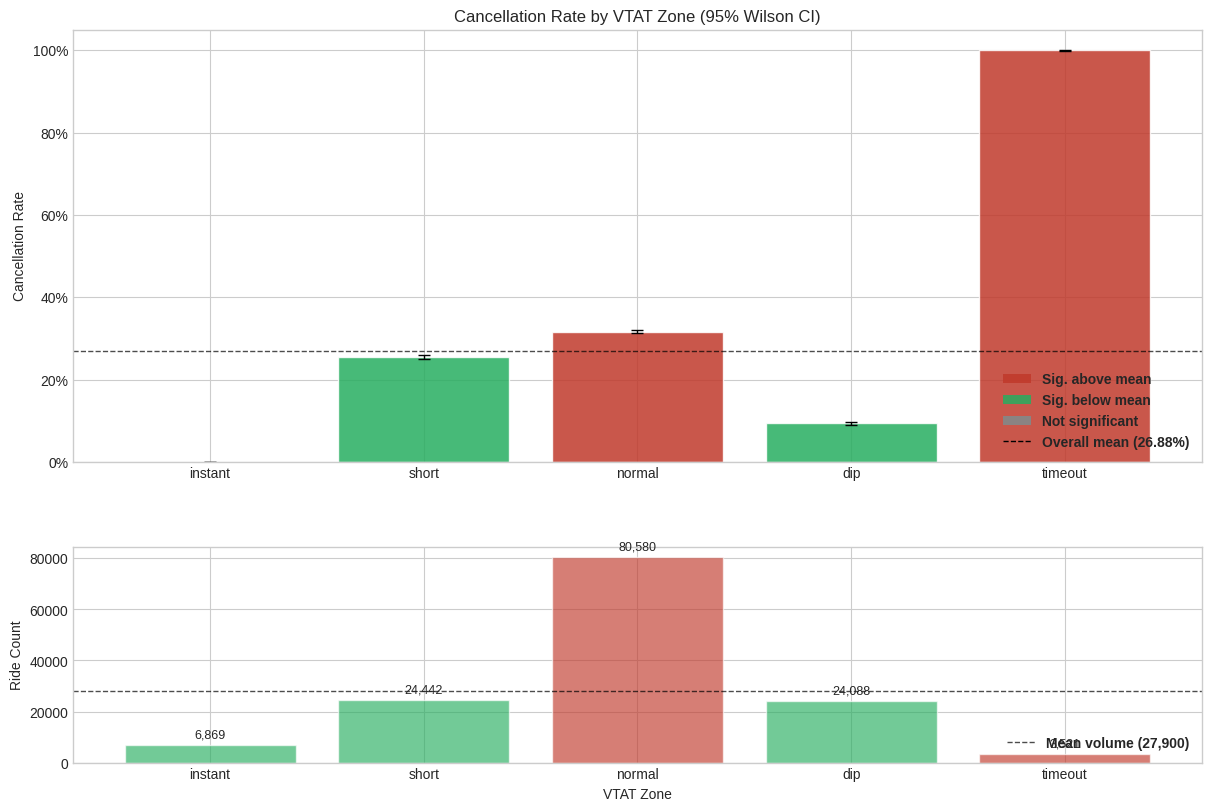


Chi-square: χ² = 16819.28, dof = 4, p = 0.0000e+00
Cramér's V = 0.3472

Categories with |standardized residual| > 2:


,Not Cancelled,Cancelled
instant,26.054986,-42.970983
short,2.613840,-4.310855
normal,-15.822856,26.095722
dip,31.792439,-52.433433
timeout,-50.739478,83.681691



All standardized residuals:


,Not Cancelled,Cancelled
instant,26.054986,-42.970983
short,2.613840,-4.310855
normal,-15.822856,26.095722
dip,31.792439,-52.433433
timeout,-50.739478,83.681691


In [28]:
zone_labels = ["instant", "short", "normal", "dip", "timeout"]
zone_results = nominal_vs_binary(
    df.dropna(subset=["vtat_zone"]),
    feature_col="vtat_zone", target_col="is_cancelled",
    labels=zone_labels,
    feature_label="VTAT Zone",
)

This is easily the most powerful feature found in the entire analysis. The "instant" and "timeout" zones are the extremes, but even the "low" and "dip" zones clearly separate from the baseline. This confirms that the non-linear structure in avg_vtat is real and strong.

#### is_instant_arrival vs target

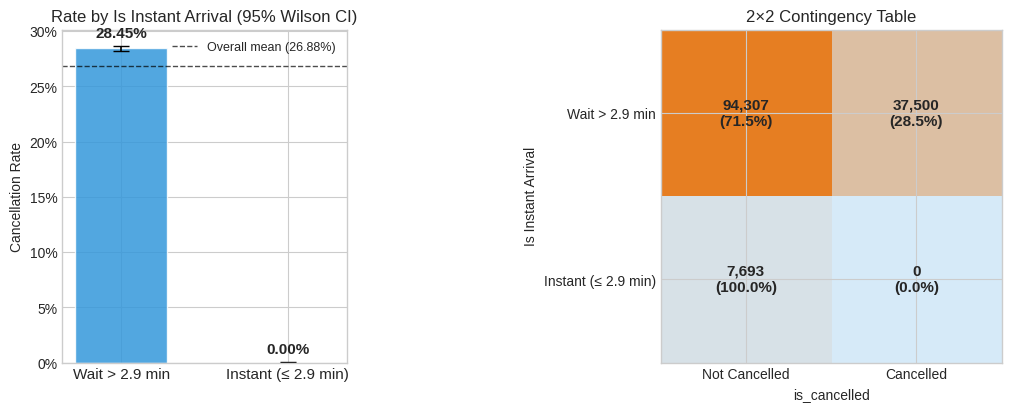

Fisher's exact test:  p = 0.0000e+00
Phi coefficient:      φ = -0.1465
  → weak negative association

Odds ratio:           OR = 0.0000  95% CI [nan, nan]
  → Is Instant Arrival=1 decreases the odds of cancellation by 100.0%


In [29]:
instant_results = binary_vs_binary(
    df.dropna(subset=["avg_vtat"]),
    feature_col="is_instant_arrival", target_col="is_cancelled",
    labels=("Wait > 2.9 min", "Instant (≤ 2.9 min)"),
    feature_label="Is Instant Arrival",
)

A perfect one-sided predictor: when the vehicle arrives in under 3 minutes, cancellation is literally zero. The OR collapses to 0 (and the CI is undefined) because there are no cancellations at all in that group. φ understates the importance here, the phi coefficient is dampened by the small proportion of rides in this bucket, but within that bucket the signal is absolute. Useful as a hard rule rather than a probabilistic feature.

#### is_timeout vs target

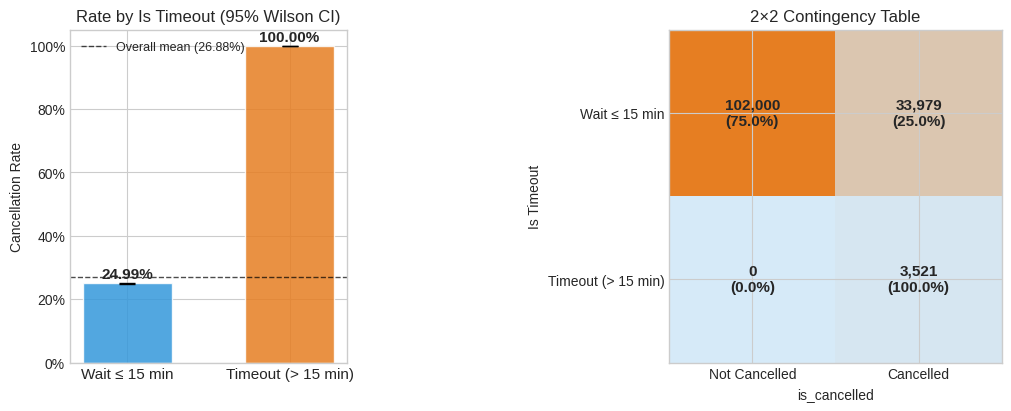

Fisher's exact test:  p = 0.0000e+00
Phi coefficient:      φ = +0.2654
  → strong positive association

Odds ratio:           OR = inf  95% CI [inf, inf]
  → Is Timeout=1 increases the odds of cancellation by inf%


In [30]:
timeout_results = binary_vs_binary(
    df.dropna(subset=["avg_vtat"]),
    feature_col="is_timeout", target_col="is_cancelled",
    labels=("Wait ≤ 15 min", "Timeout (> 15 min)"),
    feature_label="Is Timeout",
)

The mirror image of instant arrival: every ride above 15 minutes is cancelled, pushing OR to infinity and φ high. This almost certainly reflects an automatic system timeout rather than a conscious rider decision. Only 2.5% of rides fall here, but the prediction is deterministic. If this timeout is confirmed as a system rule, it should probably be handled as a business rule rather than a model feature, otherwise the model is just learning something the system already enforces.

#### is_long_wait vs target

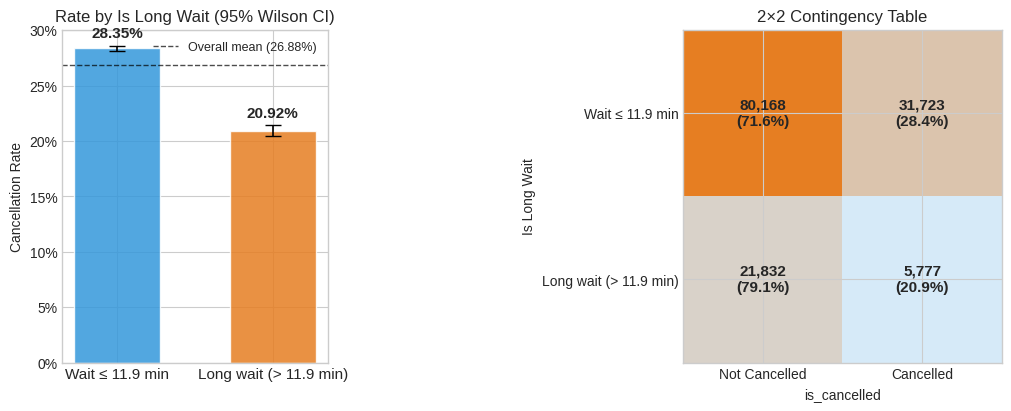

Fisher's exact test:  p = 1.2271e-142
Phi coefficient:      φ = -0.0667
  → weak negative association

Odds ratio:           OR = 0.6687  95% CI [0.6478, 0.6903]
  → Is Long Wait=1 decreases the odds of cancellation by 33.1%


In [31]:
long_results = binary_vs_binary(
    df.dropna(subset=["avg_vtat"]),
    feature_col="is_long_wait", target_col="is_cancelled",
    labels=("Wait ≤ 11.9 min", "Long wait (> 11.9 min)"),
    feature_label="Is Long Wait",
)

This one is counter-intuitive at first: rides with a wait above 12 minutes actually cancel less. φ = −0.07 is weak but highly significant. The explanation lies in the zone composition because4 it contains far more rides than the 15+ min timeout zone. So on balance, crossing the 12-minute mark means you are more likely in the committed-rider dip than in the auto-cancel timeout. This feature captures a real behavioural pattern, but it mixes two very different mechanisms, so vtat_zone is probably the cleaner choice for modelling.

### avg_vtat missingness vs target

7% of rides (10,500 rows) have a null `avg_vtat`. Before treating these as simple missing data, let's check whether the missingness itself carries signal.

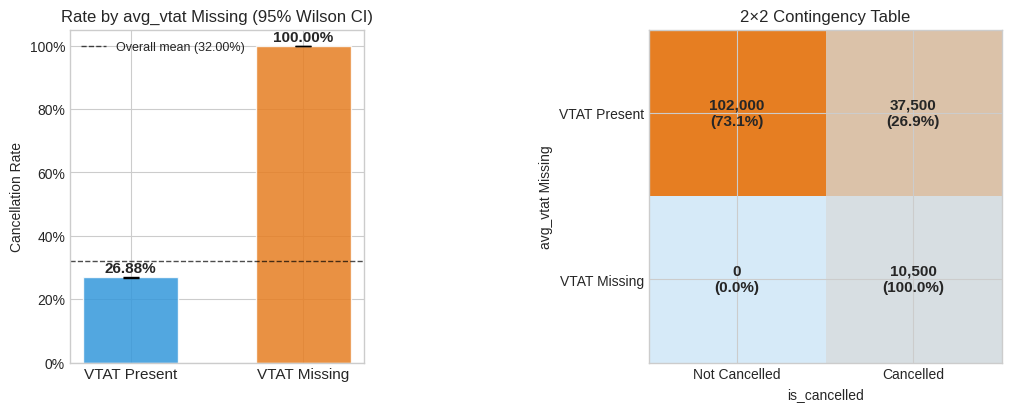

Fisher's exact test:  p = 0.0000e+00
Phi coefficient:      φ = +0.3999
  → strong positive association

Odds ratio:           OR = inf  95% CI [inf, inf]
  → avg_vtat Missing=1 increases the odds of cancellation by inf%


In [32]:
df["vtat_missing"] = df["avg_vtat"].isna().astype(int)

missing_results = binary_vs_binary(
    df, feature_col="vtat_missing", target_col="is_cancelled",
    labels=("VTAT Present", "VTAT Missing"),
    feature_label="avg_vtat Missing",
)

In [ ]:
miss_summary = []
for col, label in [("vehicle_type", "Vehicle Type"), ("hour", "Hour"),
                    ("weekday", "Weekday"), ("pickup_location", "Pickup Location")]:
    grp = df.groupby(col, observed=True)["vtat_missing"].mean()
    miss_summary.append({
        "Feature": label,
        "Categories": f"{grp.nunique()}",
        "Miss Rate (min)": f"{grp.min():.2%}",
        "Miss Rate (max)": f"{grp.max():.2%}",
        "Spread": f"{grp.max() - grp.min():.2%}",
    })

miss_df = pd.DataFrame(miss_summary)
display(miss_df)

cancel_in_missing = (df[df["vtat_missing"] == 1]
                     .groupby("vehicle_type", observed=True)["is_cancelled"]
                     .mean())
print(f"\nCancel rate among missing-vtat rides: {cancel_in_missing.unique()[0]:.0%} "
      f"(identical across all {len(cancel_in_missing)} vehicle types)")

Every ride with a missing `avg_vtat` was cancelled — 100%, no exceptions, regardless of vehicle type, hour, weekday or location. The table above confirms that the miss rate is nearly uniform across all features (~7% ± a small spread), so no single dimension explains it.

This points to pre-dispatch cancellations: the rider cancelled before a vehicle was assigned, so no arrival time was ever recorded. It's not missing data — it's a direct consequence of the outcome, which makes `vtat_missing` a leaky feature. For modelling, these 10,500 rows should either be excluded or handled as a separate segment.